In [1]:
import datetime
import http
import json
import pathlib
import re
import os
import subprocess

import cycler
from IPython.display import display, Markdown
import matplotlib.pyplot
import numpy
import polars
from tqdm.notebook import tqdm

EVALUATION_DIR = pathlib.Path.cwd() / "06_1evaluation"

os.environ["EVALUATION_DIR"] = str(EVALUATION_DIR)

# Running the Experiments

##### Terminal 1 (on remote proxy host)

```console
$ cd 06_1evaluation  # TBD reflect rename
$ script -fq output-dataset/docker-compose-remote-$(date "+%s").log
$ ./start_remote_setup.sh up
...
 ✔ Network 06_1evaluation_remote           Created                                                                                    0.1s
 ✔ Container 06_1evaluation-remote-proxy-1 Created                                                                                    0.1s
Attaching to remote-proxy-1
```

##### Terminal 2 (on local proxy host)

```console
$ cd 06_1evaluation  # TBD reflect rename
$ script -fq output-dataset/docker-compose-local-$(date "+%s").log
$ TRANCO_LOWER_LIMIT=0 TRANCO_UPPER_LIMIT=100 LIGHTHOUSE_LOG_EXTRA="<note on remote proxy, e.g. location>" PUID=$(id -u) PGID=$(id -g) PROXY_REMOTE_HOST="<remote proxy hostname or IPv4 address>" ./start_local_setup.sh up
...
lighthouse-1   | Updating certificates in /etc/ssl/certs...
lighthouse-1   | rehash: warning: skipping ca-certificates.crt, it does not contain exactly one certificate or CRL
lighthouse-1   | 1 added, 0 removed; done.
lighthouse-1   | Running hooks in /etc/ca-certificates/update.d...
lighthouse-1   | done.
lighthouse-1   | Please configure the local proxy and Chrome with the mitmproxy
lighthouse-1   | certificates. For the local proxy use docker `exec` with bash
lighthouse-1   | and configure them for a Debian system. For Chrome go to
lighthouse-1   | https://localhost:3001. See
lighthouse-1   | https://docs.mitmproxy.org/archive/v12/concepts/certificates/
lighthouse-1   | for how to do that. Set the DNS provider of Chrome to
lighthouse-1   | https://dns.google/dns-query and use docker `exec` to
lighthouse-1   | `touch ~/tls_configured`. The experiments will start
lighthouse-1   | shortly after. You can then close the https://localhost:3001 tab.
lighthouse-1   |
lighthouse-1   | DO NOT CLOSE CHROME WITHIN THAT TAB!
...
```

##### Terminal 3 (on local proxy host)

```console
$ cd 06_1evaluation  # TBD reflect rename
$ rsync -avz "<remote proxy SSH user>@<remote proxy SSH host>:<path to repo on remote proxy>/06_1evaluation/mitmproxy-remote/mitmproxy-ca-cert.pem mitmproxy-remote/"; ./start_local_setup.sh exec -ti local-proxy /app/update_certificate.sh /mitmproxy-remote/mitmproxy-ca-cert.pem
```

##### In Browser via https://localhost:3001 (on local proxy host)

Chrome Version (2026-04-22): 147.0.7727.101

1. **Create an exception for self-signed certificate of localhost:3001**
2.  

##### On certificate errors

**Terminal 1 (on remote proxy host):**
``` console
$ ./start_remote_setup.sh down
```

**Terminal 2 (on local proxy host):**

```console
$ TRANCO_LOWER_LIMIT=0 TRANCO_UPPER_LIMIT=100 LIGHTHOUSE_LOG_EXTRA="<note on remote proxy, e.g. location>" PUID=$(id -u) PGID=$(id -g) PROXY_REMOTE_HOST="<remote proxy hostname or IPv4 address>" ./start_local_setup.sh down
```

Restart from top

##### Start experiment in Terminal 3 (on local proxy host)

```console
$ ./start_local_setup.sh exec -ti lighthouse touch /config/tls_configured
```

# Merge Lighthouse Reports

In [2]:
fcps = []
jsons = list((EVALUATION_DIR / "output-dataset").glob("lighthouse-run-*.report.json"))

for json_report in tqdm(jsons):
    with open(json_report) as json_file:
        obj = json.load(json_file)
        match = re.match(r"lighthouse-run-(?P<domain>.*)-(?P<run>\d{3})-(?P<compress>true|false)-(?P<packed>true|false)-(?P<lhts>\d+)(?P<extra>.*)?\.report\.json", json_report.name)
        res = match.groupdict()
        res["run"] = int(res["run"])
        res["lhts"] = int(res["lhts"])
        if res["run"] == 0:
            # ignore cache warm-up run
            continue
        try:
            fcp = obj["audits"]["first-contentful-paint"]["numericValue"]
            error = None
        except KeyError:
            fcp = None
            try:
                error = obj["runtimeError"]["code"]
            except KeyError:
                if "errorMessage" in obj["audits"].get("first-contentful-paint", {}):
                    error = "NO_FCP"
                else:
                    display(obj)
                    raise

            if error == "ERRORED_DOCUMENT_REQUEST":
                match = re.search(r"Status code: (\d+)", obj["runtimeError"]["message"])
                error = f"{error} (Status: {match[1]})"
        if not error:
            rtt = obj["audits"]["network-rtt"].get("numericValue")
            lcp = obj["audits"]["largest-contentful-paint"].get("numericValue")
            speed_index = obj["audits"]["speed-index"].get("numericValue")
            total_blocking_time = obj["audits"]["total-blocking-time"].get("numericValue")
            cumulative_layout_shift = obj["audits"]["cumulative-layout-shift"].get("numericValue")
        else:
            rtt = None
            lcp = None
            speed_index = None
            total_blocking_time = None
            cumulative_layout_shift = None
        res["compress"] = res["compress"] == "true"
        res["packed"] = res["packed"] == "true"
        res["extra"] = res["extra"].strip("-_")
        res["rtt"] = rtt
        res["fcp"] = fcp
        res["lcp"] = lcp
        res["speed_index"] = speed_index
        res["total_blocking_time"] = total_blocking_time
        res["cumulative_layout_shift"] = cumulative_layout_shift
        res["error"] = error
        res["filename"] = json_report.name
        fcps.append(res)

if not fcps:
    raise RuntimeError("No valid results yet")
df = polars.DataFrame(
    fcps,
    infer_schema_length=len(fcps),
).unique(subset=["filename"]).sort("lhts").rename(
    {
        "lhts": "lighthouse_timestamp",
        "fcp": "first_contentful_paint",
        "lcp": "largest_contentful_paint",
    }
).with_columns(
    polars.from_epoch(
        polars.col("lighthouse_timestamp")
    ).dt.convert_time_zone(time_zone="Europe/Berlin")
)
df.write_parquet(
    EVALUATION_DIR / "output-dataset" / "lighthouse.parquet",
    compression="zstd",
    compression_level=22,
)

  0%|          | 0/8814 [00:00<?, ?it/s]

# Plot Boxplot

metric,location,max. runs,successful domains,successful unique domains,min.,max.,mean,std.,median
str,str,i64,f64,i64,f64,f64,f64,f64,f64
"""first_contentful_paint""","""Oregon, US""",6,124.166667,127,-2144.5801,4083.84875,127.306259,687.494395,54.763667
"""largest_contentful_paint""","""Oregon, US""",6,124.166667,127,-29944.916778,28509.914833,-37.003032,4145.024013,39.455167
"""speed_index""","""Oregon, US""",6,124.166667,127,-7869.850046,20417.715392,359.926732,2554.116566,171.566984
"""total_blocking_time""","""Oregon, US""",6,124.166667,127,-1259.185417,1515.820275,-46.808548,254.536804,-13.833333
"""rtt""","""Oregon, US""",6,124.166667,127,-345.051665,314.137177,1.417785,56.636848,-0.031667


metric,location,max. runs,successful domains,successful unique domains,min.,max.,mean,std.,median
str,str,i64,f64,i64,f64,f64,f64,f64,f64
"""first_contentful_paint""","""Johannesburg, ZA""",5,121.6,124,-1322.936183,2036.6258,36.268561,459.036316,8.73755
"""largest_contentful_paint""","""Johannesburg, ZA""",5,121.6,124,-8913.13038,7051.62718,25.584722,1578.099094,31.1827
"""speed_index""","""Johannesburg, ZA""",5,121.6,124,-3802.417477,12929.112287,163.79012,1718.764186,36.90194
"""total_blocking_time""","""Johannesburg, ZA""",5,121.6,124,-1015.354,631.7656,-8.885807,165.507025,-0.3
"""rtt""","""Johannesburg, ZA""",5,121.6,124,-200.783984,419.4418,1.509345,46.822875,-0.024


metric,location,max. runs,successful domains,successful unique domains,min.,max.,mean,std.,median
str,str,i64,f64,i64,f64,f64,f64,f64,f64
"""first_contentful_paint""","""Jakarta, ID""",5,120.4,125,-3073.829069,2171.9234,-26.863088,617.422948,5.3128
"""largest_contentful_paint""","""Jakarta, ID""",5,120.4,125,-8417.0913,6467.242698,-122.238219,1737.374324,29.6021
"""speed_index""","""Jakarta, ID""",5,120.4,125,-5550.785583,10179.941621,212.330418,1728.753362,69.876141
"""total_blocking_time""","""Jakarta, ID""",5,120.4,125,-968.1835,1889.4955,42.898884,371.451836,0.0
"""rtt""","""Jakarta, ID""",5,120.4,125,-259.237692,860.967454,12.84123,110.595764,0.0314


## [Lighthouse Metrics (Box Plot)](06_1evaluation/plots/lighthouse-box.pdf)

LCP measures paint time of largest images, videos, and textblocks, so only small improvements are to be expected.

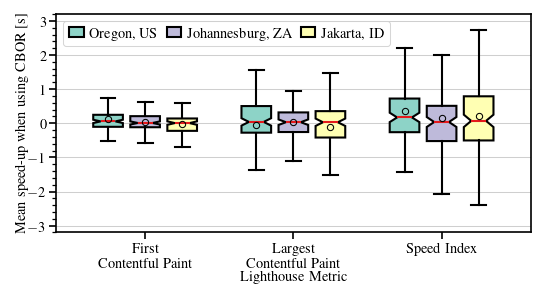

In [3]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 6 / 8,
)

df = polars.read_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()
stats = None
METRICS = [
    "first_contentful_paint",
    "largest_contentful_paint",
    "speed_index",
    "total_blocking_time",
    "rtt",
]

BOXPLOT_COLORS={
    "us-west": matplotlib.colormaps["Set3"].colors[0],
    "indonesia": matplotlib.colormaps["Set3"].colors[1],
    "africa-south": matplotlib.colormaps["Set3"].colors[2],
}

METRIC_XAXIS_LABEL = {
    "first_contentful_paint": "First\nContentful Paint",
    "largest_contentful_paint": "Largest\nContentful Paint",
    "speed_index": "Speed Index",
    "total_blocking_time": "Total\nBlocking Time",
    "rtt": "RTT",
}
LOCATIONS = {
    "us-west": "Oregon, US",
    "indonesia": "Jakarta, ID",
    "africa-south": "Johannesburg, ZA",
}
LOCATIONS_SORTED = [
    "us-west",
    "africa-south",
    "indonesia",
]
LOCATION_OFFSET = {
    "africa-south": 0.0,
    "us-west": -0.25,
    "indonesia": 0.25,
}
WIDTH = 0.3

for i, location in enumerate(LOCATIONS_SORTED):
    times = df.filter(~polars.col("packed") & (polars.col("extra") == location)).select(
        ["compress", "domain", "run"] + METRICS
    ).pivot(
        "compress",
        index=["domain", "run"],
        values=METRICS,
    ).with_columns(
        **{
            # ~compressed - compressed
            k: polars.col(f"{k}_false") - polars.col(f"{k}_true")
            for k in METRICS
        }
    ).filter(
        polars.col("first_contentful_paint").is_not_null()
        & polars.col("largest_contentful_paint").is_not_null()
        & polars.col("speed_index").is_not_null()
        & polars.col("total_blocking_time").is_not_null()
        & polars.col("rtt").is_not_null()
    ).select(
        ["domain"] + METRICS
    ).group_by(["domain"]).agg(polars.all().mean(), polars.col("domain").len().alias("runs"))
    stats = polars.DataFrame(
        [
            {
                "metric": k,
                "location": LOCATIONS[location],
                "max. runs": times["runs"].max(),
                # some websites do not load every time, so count the websites fractionally, based on the successful runs with
                # this webside
                "successful domains": times.group_by("domain").agg(polars.col("runs").sum() / times["runs"].max())["runs"].sum(),
                "successful unique domains": times["domain"].unique().len(),
                "min.": times[k].min(),
                "max.": times[k].max(),
                "mean": times[k].mean(),
                "std.": times[k].std(),
                "median": times[k].median(),
            }
            for k in METRICS
        ],
    )

    display(stats)
    bxplt = ax.boxplot(
        times.select(METRICS).select(polars.exclude(["rtt", "total_blocking_time"])),
        positions=numpy.arange(1, len(METRICS) - 1) + LOCATION_OFFSET[location],
        notch=True,
        widths=WIDTH - .1,
        showfliers=False,
        showmeans=True,
        patch_artist=True,
        label=LOCATIONS[location],
        meanprops={"marker": ".", "markeredgecolor": "black", "markerfacecolor": "none"},
        medianprops={"c": matplotlib.colormaps["Set1"].colors[0]},
    )
    for patch in bxplt['boxes']:
        patch.set_facecolor(BOXPLOT_COLORS[location])
        patch.set_linewidth(1)
ax.set_axisbelow(True)
ax.grid(axis="y")
ax.set_xlim(0.4, 3.6)
ax.set_xlabel(f"Lighthouse Metric")
ax.set_xticks(range(1, len(METRICS) - 1), [METRIC_XAXIS_LABEL[m] for m in METRICS if m not in ["rtt", "total_blocking_time"]])
ax.set_ylabel(f"Mean speed-up when using CBOR [s]")
ax.set_ylim(-3200, 3200)
ax.set_yticks(numpy.arange(-3000, 3300, 1000))
ax.set_yticks(numpy.arange(-3200, 3300, 200), minor=True)
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, pos: f"${y / 1000.0:.0f}$"))
ax.legend(loc="upper left", ncol=3)
filepath = EVALUATION_DIR / "plots" / "lighthouse-box.pdf"
display(
    Markdown(
        f"## [Lighthouse Metrics (Box Plot)]({str(filepath.relative_to(pathlib.Path.cwd()))})\n\nLCP measures paint time of largest images, videos, and textblocks, so only small improvements are to be expected."
    )
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

# Analyze Lighthouse Errors

In [4]:
errors = df.filter(
    polars.col("error").is_not_null()
).select(
    ["domain", "run", "extra", "compress", "error"]
)
with polars.Config(fmt_str_lengths=df["error"].str.len_chars().max()): #, tbl_rows=162):
    display(
        errors.pivot(
            "run",
            index=["domain", "compress", "extra"],
            values="error"
        ).rename(
            {
                str(k): f"run_{k:02d}"
                for k in range(1, df["run"].max() + 1)
            }
        ).lazy().join(
            polars.scan_csv(EVALUATION_DIR / "tranco_3QL4L.csv", has_header=False, new_columns=["rank", "domain"]),
            on="domain",
        ).select(
            ["rank", "domain", "extra", "compress"] + [f"run_{k:02d}" for k in range(1, df["run"].max() + 1)]
        ).sort(["rank", "extra", "compress"]).collect()
    )
error_summary = errors.group_by("error").agg(
    polars.col("error").len().alias("count"),
).with_columns(
    polars.col("error").str.replace(
        r"ERRORED_DOCUMENT_REQUEST \(Status: ([0-9]+)\)", "${1}"
    ).map_elements(
        lambda x: (
            f"HTTP error: {http.HTTPStatus(int(x)).phrase} ({x})"
            if int(x) in http.HTTPStatus
            else f"HTTP error: CDN Connection Timed Out ({x})"
        ) if x.isdigit() else x,
        return_dtype=polars.String,
    )
).with_columns(
    error_ratio=(polars.col("count") / df["domain"].len())
)
error_summary = polars.concat(
    [
        error_summary,
        polars.DataFrame([{"error": "No audit error", "count": None, "error_ratio": 1.0 - error_summary["error_ratio"].sum()}])
    ]
).sort("error_ratio")
with polars.Config(fmt_str_lengths=error_summary["error"].str.len_chars().max()):
    display(error_summary)

rank,domain,extra,compress,run_01,run_02,run_03,run_04,run_05,run_06,run_07
i64,str,str,bool,str,str,str,str,str,str,str
2,"""gtld-servers.net""","""africa-south""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""",null,null
2,"""gtld-servers.net""","""africa-south""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""",null,null
2,"""gtld-servers.net""","""indonesia""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""",null,null
2,"""gtld-servers.net""","""indonesia""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""",null,null
2,"""gtld-servers.net""","""us-west""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""",null
…,…,…,…,…,…,…,…,…,…,…
1000000,"""aaacompany.net""","""africa-south""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""",null,null
1000000,"""aaacompany.net""","""indonesia""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""",null,null
1000000,"""aaacompany.net""","""indonesia""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""",null,null


error,count,error_ratio
str,u64,f64
"""HTTP error: CDN Connection Timed Out (522)""",4,0.000624
"""HTTP error: Unavailable For Legal Reasons (451)""",12,0.001873
"""HTTP error: Bad Request (400)""",32,0.004995
"""NOT_HTML""",32,0.004995
"""HTTP error: Forbidden (403)""",126,0.019666
"""HTTP error: Not Found (404)""",162,0.025285
"""NO_FCP""",465,0.072577
"""HTTP error: Bad Gateway (502)""",491,0.076635
"""CHROME_INTERSTITIAL_ERROR""",1128,0.176057


# Review Current Experiment Progress

In [5]:
lf = df.select(["domain", "extra", "run", "error"]).group_by(["domain", "extra"]).agg(polars.col("run").len().alias("runs"), polars.col("error")).with_columns(
    polars.col("runs") / 2   # compressed and uncompressed runs are counted here together so devide by 2
).lazy().join(
    polars.scan_csv(EVALUATION_DIR / "tranco_3QL4L.csv", has_header=False, new_columns=["rank", "domain"]),
    on="domain",
).sort(["rank", "extra"]).select(["rank", "domain", "extra", "runs", "error"])
with polars.Config(tbl_rows=df.shape[0]):
    display(lf.collect())

rank,domain,extra,runs,error
i64,str,str,f64,list[str]
1,"""google.com""","""africa-south""",5.0,"[null, null, … null]"
1,"""google.com""","""indonesia""",5.0,"[null, null, … null]"
1,"""google.com""","""us-west""",6.5,"[null, null, … null]"
2,"""gtld-servers.net""","""africa-south""",5.0,"[""CHROME_INTERSTITIAL_ERROR"", ""CHROME_INTERSTITIAL_ERROR"", … ""CHROME_INTERSTITIAL_ERROR""]"
2,"""gtld-servers.net""","""indonesia""",5.0,"[""CHROME_INTERSTITIAL_ERROR"", ""CHROME_INTERSTITIAL_ERROR"", … ""CHROME_INTERSTITIAL_ERROR""]"
2,"""gtld-servers.net""","""us-west""",6.5,"[""CHROME_INTERSTITIAL_ERROR"", ""CHROME_INTERSTITIAL_ERROR"", … ""CHROME_INTERSTITIAL_ERROR""]"
3,"""gstatic.com""","""africa-south""",5.0,"[""ERRORED_DOCUMENT_REQUEST (Status: 404)"", ""ERRORED_DOCUMENT_REQUEST (Status: 404)"", … ""ERRORED_DOCUMENT_REQUEST (Status: 404)""]"
3,"""gstatic.com""","""indonesia""",5.0,"[""ERRORED_DOCUMENT_REQUEST (Status: 404)"", ""ERRORED_DOCUMENT_REQUEST (Status: 404)"", … ""ERRORED_DOCUMENT_REQUEST (Status: 404)""]"
3,"""gstatic.com""","""us-west""",6.5,"[""ERRORED_DOCUMENT_REQUEST (Status: 404)"", ""ERRORED_DOCUMENT_REQUEST (Status: 404)"", … ""ERRORED_DOCUMENT_REQUEST (Status: 404)""]"


# Extract Proxy Logs

In [6]:
lhtss = polars.scan_parquet(
    EVALUATION_DIR / "output-dataset" / "lighthouse.parquet"
).select("lighthouse_timestamp").unique().collect()["lighthouse_timestamp"].implode()

for proxy in ["local", "remote"]:
    with subprocess.Popen(
        "awk -F'\t' '$1 ~ /ROW/ || "
        "$1 ~ /marker/ {print $0}' \"${EVALUATION_DIR}/output-dataset/"
        f"docker-compose-{proxy}-\"*.log",
        stdout=subprocess.PIPE,
        shell=True
    ) as proc:
        polars.scan_csv(
            proc.stdout.read(),
            separator="\t",
            infer_schema=False,  # do not infer schema as header might repeat (see filter below)
        ).select(
            polars.exclude("^.+marker$")
        ).filter(
            polars.col("timestamp") != "timestamp"  # skip header repetitions
        ).with_columns(
            polars.from_epoch(
                polars.col("lhts").cast(polars.Int32),
                time_unit="s",
            ).dt.convert_time_zone(time_zone="Europe/Berlin"),
        ).filter(
            polars.col("lhts").is_in(lhtss)
        ).with_columns(
            polars.from_epoch(
                polars.col("timestamp").cast(polars.Float64)
            ).dt.convert_time_zone(time_zone="Europe/Berlin"),
            polars.col("domain_rank").cast(polars.Int32),
            polars.col("run").cast(polars.Int8),
            polars.col("convert").str.to_lowercase() == "true",
            polars.col("packed").str.to_lowercase() == "true",
            polars.col("response_status").cast(polars.Int16),
            polars.col("orig_body_length").cast(polars.Int64),
            polars.col("orig_content_length").cast(polars.Int64),
            polars.col("new_body_length").cast(polars.Int64),
            polars.col("query_missing").str.to_lowercase() == "true",
            polars.col("handler_time").cast(polars.Float64),
        ).sink_parquet(
            EVALUATION_DIR / "output-dataset" / f"mitmproxy-{proxy}.parquet",
            compression="zstd",
            compression_level=22,
        )

# Analyze Request/Response Make-Up

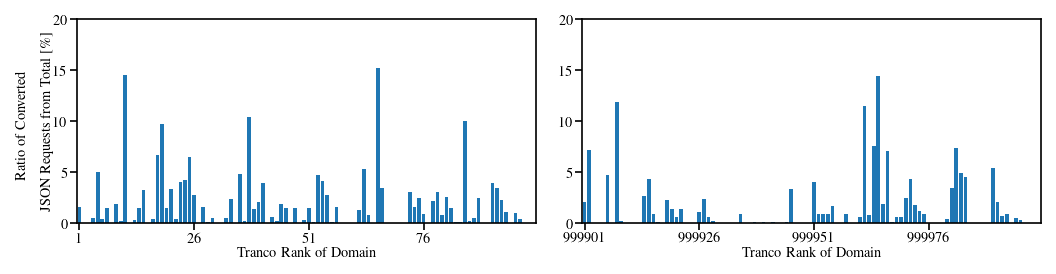

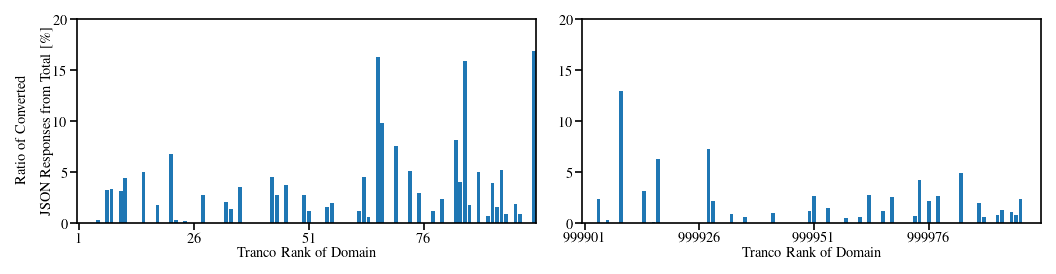

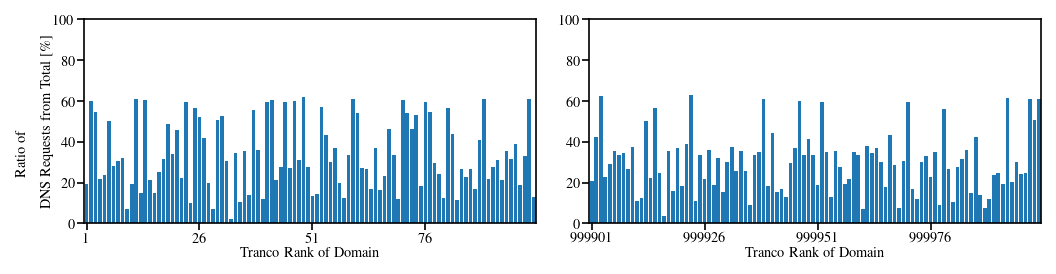

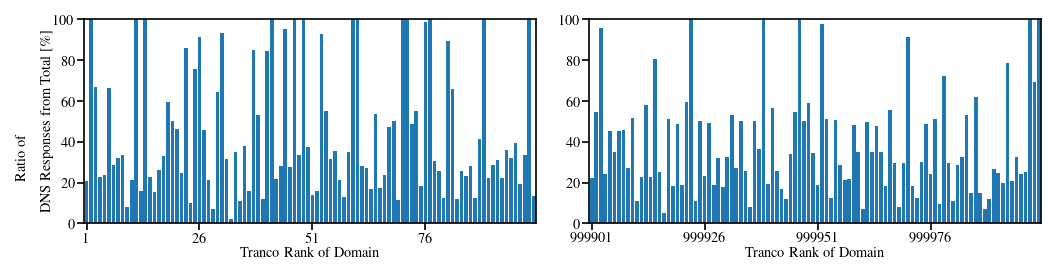

In [7]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullwidth_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 7 / 8,
)

logs_lf = polars.scan_parquet(
    EVALUATION_DIR / "output-dataset" / "mitmproxy-local.parquet"
).filter(polars.col("domain").is_not_null() & ~polars.col("packed"))

requests = logs_lf.filter(polars.col("response_status").is_null())
responses = logs_lf.filter(polars.col("response_status").is_not_null())
converted_reqs = requests.filter(polars.col("msg").str.starts_with("Converted "))
converted_resps = responses.filter(polars.col("msg").str.starts_with("Converted "))
converted_json_reqs = converted_reqs.filter(polars.col("msg").str.contains("JSON"))
converted_json_resps = converted_resps.filter(polars.col("msg").str.contains("JSON"))
converted_dns_reqs = converted_reqs.filter(polars.col("msg").str.contains("DNS"))
converted_dns_resps = converted_resps.filter(polars.col("msg").str.contains("DNS"))

stats_df = requests.group_by(
    ["domain", "domain_rank", "run", "convert"]
).agg(reqs_count=polars.col("msg").len()).join(
    responses.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_reqs.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(converted_reqs_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_resps.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(converted_resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_json_reqs.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(json_reqs_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_json_resps.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(json_resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_dns_reqs.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(dns_reqs_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_dns_resps.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(dns_resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).sort(["domain_rank", "run", "convert"]).with_columns(
    polars.col("converted_reqs_count").fill_null(0) / polars.col("reqs_count"),
    polars.col("converted_resps_count").fill_null(0) / polars.col("resps_count"),
    polars.col("json_reqs_count").fill_null(0) / polars.col("reqs_count"),
    polars.col("json_resps_count").fill_null(0) / polars.col("resps_count"),
    polars.col("dns_reqs_count").fill_null(0) / polars.col("reqs_count"),
    polars.col("dns_resps_count").fill_null(0) / polars.col("resps_count"),
).group_by(
    ["domain", "domain_rank", "convert"]
).mean().select(polars.exclude("run")).sort(["domain_rank", "convert"]).collect()

msg_diff = stats_df.filter(polars.col("convert")).select(
    ["domain", "domain_rank", "reqs_count", "resps_count"]
).join(
    stats_df.filter(~polars.col("convert")).select(
        ["domain", "domain_rank", "reqs_count", "resps_count"]
    ),
    ["domain", "domain_rank"],
    "right",
).with_columns(
    reqs_diff=polars.col("reqs_count") - polars.col("reqs_count_right"),
    resps_diff=polars.col("resps_count") - polars.col("resps_count_right"),
)
HUMAN = {
    "reqs": "Requests",
    "resps": "Responses",
}

stats_df = stats_df.filter(polars.col("convert") == True)

for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(stats_df.filter(filt)["domain_rank"], stats_df.filter(filt)[f"json_{msg}_count"])
        ax.set_xlim(stats_df.filter(filt)["domain_rank"].min() - 0.5, stats_df.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                stats_df.filter(filt)["domain_rank"].min(),
                stats_df.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 0.2)
        ax.ticklabel_format(useOffset=False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel(fr"Ratio of Converted\\JSON {HUMAN[msg]} from Total [\%]")
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:.0f}$"))
    fig.tight_layout()
    matplotlib.pyplot.show()


for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(stats_df.filter(filt)["domain_rank"], stats_df.filter(filt)[f"dns_{msg}_count"])
        ax.set_xlim(stats_df.filter(filt)["domain_rank"].min() - 0.5, stats_df.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                stats_df.filter(filt)["domain_rank"].min(),
                stats_df.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 1)
        ax.ticklabel_format(useOffset=False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel(fr"Ratio of\\DNS {HUMAN[msg]} from Total [\%]")
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:.0f}$"))
    fig.tight_layout()
    matplotlib.pyplot.show()

domain,domain_rank,reqs_byte_savings,resps_byte_savings
str,i32,f64,f64


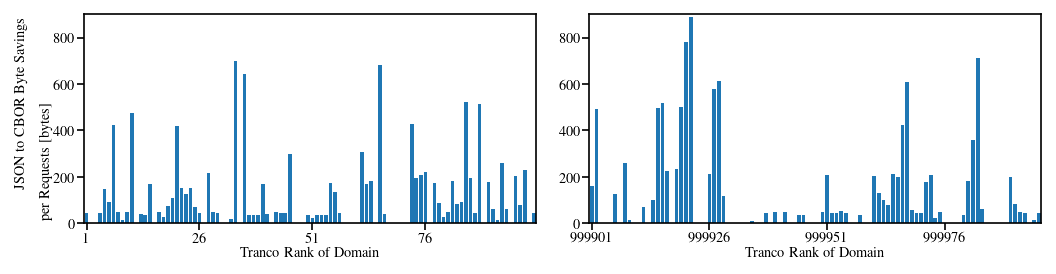

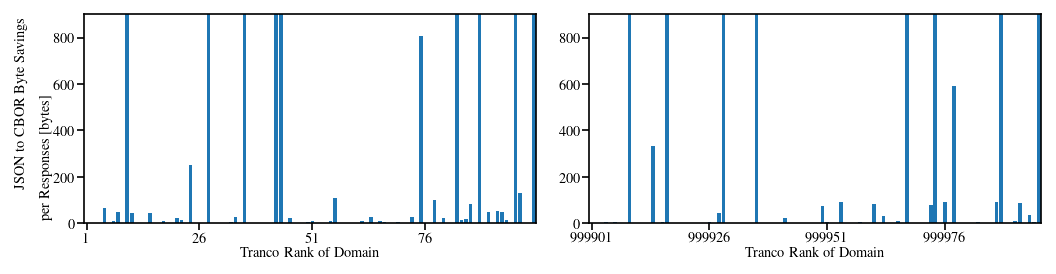

In [8]:
json_byte_savings = converted_json_reqs.with_columns(
    byte_savings=polars.col("orig_body_length") - polars.col("new_body_length"),
).group_by(
    ["domain", "domain_rank"]
).agg(polars.col("byte_savings").mean().alias("reqs_byte_savings")).join(
    converted_json_resps.with_columns(
        byte_savings=polars.col("new_body_length") - polars.col("orig_body_length"),
    ).group_by(
        ["domain", "domain_rank"]
    ).agg(polars.col("byte_savings").mean().alias("resps_byte_savings")),
    ["domain", "domain_rank"],
    "full"
).with_columns(
    domain_rank=polars.when(
        polars.col("domain_rank").is_null()
    ).then(
        polars.col("domain_rank_right")
    ).otherwise(
        polars.col("domain_rank")
    ),
    domain=polars.when(
        polars.col("domain").is_null()
    ).then(
        polars.col("domain_right")
    ).otherwise(
        polars.col("domain")
    ),
).select(polars.exclude("^.*_right$")).sort("domain_rank").collect()
display(json_byte_savings.filter(polars.col("reqs_byte_savings") > 1500))

for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(json_byte_savings.filter(filt)["domain_rank"], json_byte_savings.filter(filt)[f"{msg}_byte_savings"])
        ax.set_xlim(json_byte_savings.filter(filt)["domain_rank"].min() - 0.5, json_byte_savings.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                json_byte_savings.filter(filt)["domain_rank"].min(),
                json_byte_savings.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 900)
        ax.ticklabel_format(useOffset=False)
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel(fr"JSON to CBOR Byte Savings\\per {HUMAN[msg]} [bytes]")
    fig.tight_layout()
    matplotlib.pyplot.show()

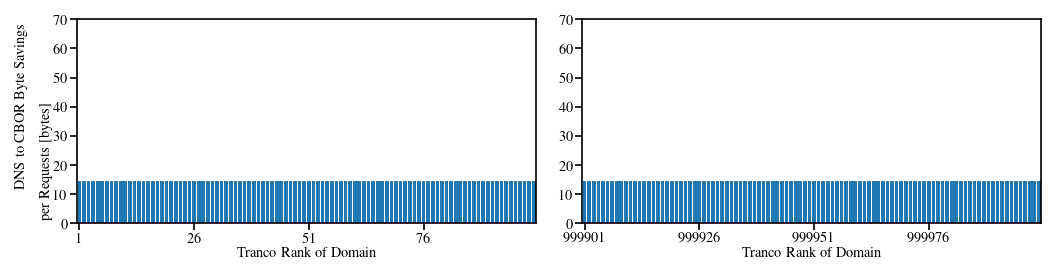

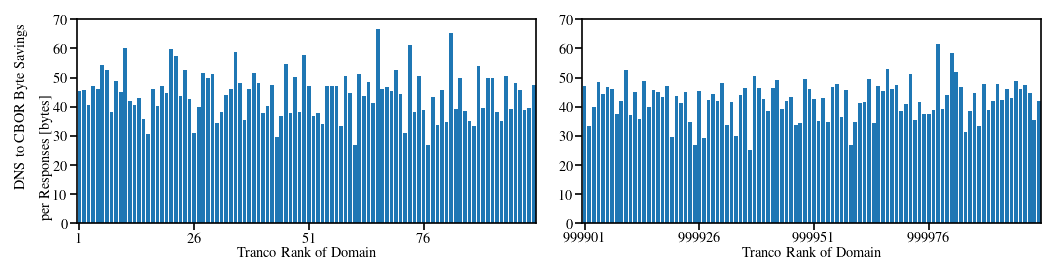

In [9]:
dns_byte_savings = converted_dns_reqs.with_columns(
    byte_savings=polars.col("orig_body_length") - polars.col("new_body_length"),
).group_by(
    ["domain", "domain_rank"]
).agg(polars.col("byte_savings").mean().alias("reqs_byte_savings")).join(
    converted_dns_resps.with_columns(
        byte_savings=polars.col("new_body_length") - polars.col("orig_body_length"),
    ).group_by(
        ["domain", "domain_rank"]
    ).agg(polars.col("byte_savings").mean().alias("resps_byte_savings")),
    ["domain", "domain_rank"],
    "full"
).with_columns(
    domain_rank=polars.when(
        polars.col("domain_rank").is_null()
    ).then(
        polars.col("domain_rank_right")
    ).otherwise(
        polars.col("domain_rank")
    ),
    domain=polars.when(
        polars.col("domain").is_null()
    ).then(
        polars.col("domain_right")
    ).otherwise(
        polars.col("domain")
    ),
).select(polars.exclude("^.*_right$")).sort("domain_rank").collect()

for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(dns_byte_savings.filter(filt)["domain_rank"], dns_byte_savings.filter(filt)[f"{msg}_byte_savings"])
        ax.set_xlim(dns_byte_savings.filter(filt)["domain_rank"].min() - 0.5, dns_byte_savings.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                dns_byte_savings.filter(filt)["domain_rank"].min(),
                dns_byte_savings.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 70)
        ax.ticklabel_format(useOffset=False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel(fr"DNS to CBOR Byte Savings\\per {HUMAN[msg]} [bytes]")
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
    fig.tight_layout()
    matplotlib.pyplot.show()